# KNN Hyperparameter Tuning, Nested Cross-Validation

Select hyperparameters (pooling, neighbor weighting, distance metric, K) via a **single-level** 
5-fold position-grouped `GroupKFold`: the same fold split is used both to score all 32 
(weights x metric x K) configurations and to report the winning configuration's performance. 
That is a mild form of the same leakage this project has repeatedly fixed elsewhere -- 
the reported rho is optimistic because the model selection and the performance estimate
share the same held-out data.

**Nested cross-validation**:

- **Outer loop**: 5-fold, position-grouped (`GroupKFold`). Each outer fold's positions are held out
  entirely during that fold's hyperparameter search and model fit.
- **Inner loop**: within the remaining four outer-training folds' positions only, a 3-fold
  position-grouped `GroupKFold` scores the **full grid** -- all 2 (pooling) x 2 (weighting) x
  2 (metric) x 8 (K) = 64 configurations -- by inner-OOF Spearman rho on the outer-training positions only.
- The **inner winner** (highest inner-OOF rho) is refit on **all four** outer-training folds, then used
  to predict the held-out outer fold's variants.
- This is repeated for all 5 outer folds; the five held-out prediction sets are concatenated and a
  **single** Spearman rho is computed once, at the end, against the true activity values (one OOF rho per model).

Since each outer fold can select a different "optimal" configuration, there is no longer one single
answer to "what is the best K" -- the honest answer is however many configurations were actually chosen
across the 5 outer folds, reported below alongside their consensus (if any).

In [ ]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict

# ── Publication-quality figure defaults ─────
plt.rcParams.update({
    'figure.dpi':         150,
    'savefig.dpi':         300,
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':           11,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      12,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'legend.frameon':      True,
    'legend.framealpha':   0.85,
    'legend.facecolor':    'white',
    'legend.edgecolor':    '0.8',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.8,
    'lines.linewidth':     1.2,
})

DATA_DIR = '../data'

# Colorblind-safe palette (Okabe-Ito)
POOL_COLORS   = {'Mean': '#0072B2', 'Max': '#E69F00'}
METRIC_COLORS = {'euclidean': '#0072B2', 'cosine': '#E69F00'}
WEIGHT_STYLES = {'uniform': '-', 'distance': '--'}


def knn_spearman(X, y, groups, k=5, weights='uniform', metric='euclidean', n_splits=5, seed=42):
    """Position-grouped 5-fold OOF KNN regression; returns Spearman rho/p between
    OOF predictions and truth. Folds are grouped by residue position so that
    substitutions at the same position never split across train/test."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, weights=weights, metric=metric)),
    ])
    cv  = GroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = cross_val_predict(pipe, X, y, cv=cv, groups=groups)
    rho, p = spearmanr(oof, y)
    return rho, p

In [2]:
# ── AlphaMissense ─────────────────────────────────────────────────────────────
am = pd.read_csv(f'{DATA_DIR}/AlphaMissense-Search-P11712.tsv', sep='\t')
am.columns = am.columns.str.lstrip('# ')
am = am.rename(columns={
    'a.a.1': 'ref', 'position': 'pos', 'a.a.2': 'alt',
    'pathogenicity score': 'am_score', 'pathogenicity class': 'am_class'
})

# ── ESM-2 masked marginal log-likelihood ──────────────────────────────────────
with open(f'{DATA_DIR}/masked_marginal_prob.json') as f:
    esm2_raw = json.load(f)

esm2 = pd.DataFrame(list(esm2_raw.items()), columns=['key', 'esm2_mmp'])
esm2['mutation'] = esm2['key'].str.replace('P11712_', '', regex=False)
esm2 = esm2[['mutation', 'esm2_mmp']]

# ── DMS activity scores (same dedup fix as cyp2c9_activity_prediction.ipynb) ──
dms = pd.read_csv(f'{DATA_DIR}/cyp2c9.csv', index_col=0)
dms_ms = dms[dms['alt'] != '='].copy()
dms_ms['pos'] = dms_ms['pos'].astype(int)
dms_ms = (dms_ms.sort_values('vamp-seq_score', na_position='last')
                 .drop_duplicates(subset=['ref', 'pos', 'alt'], keep='first')
                 .sort_index())

# ── Three-way merge ───────────────────────────────────────────────────────────
merged = (
    dms_ms
    .merge(esm2, on='mutation', how='inner')
    .merge(am[['ref', 'pos', 'alt', 'am_score', 'am_class']], on=['ref', 'pos', 'alt'], how='inner')
)
fit   = merged[['mutation', 'ref', 'pos', 'alt', 'am_score', 'esm2_mmp', 'click-seq_score', 'am_class']].dropna().copy()
train = fit.dropna(subset=['click-seq_score']).copy().reset_index(drop=True)
print(f'Variants with AM + ESM-2 + click-seq (deduplicated): {len(train):,}')

Variants with AM + ESM-2 + click-seq (deduplicated): 6,141


In [3]:
# ── Build mutation -> row-index map from the ordered file list ───────────────
with open(f'{DATA_DIR}/rep_matrix_files.txt') as f:
    rep_files = [l.strip() for l in f]

rep_mutations = [fn.replace('P11712_', '').replace('.pt', '') for fn in rep_files]
mut_to_idx    = {m: i for i, m in enumerate(rep_mutations)}

rep_matrix = np.load(f'{DATA_DIR}/rep_matrix.npy', mmap_mode='r')
print(f'rep_matrix shape: {rep_matrix.shape}  dtype: {rep_matrix.dtype}')

emb_train = train[train['mutation'].isin(mut_to_idx)].copy().reset_index(drop=True)
row_idx   = [mut_to_idx[m] for m in emb_train['mutation']]

X_mean   = rep_matrix[row_idx].mean(axis=1).astype(np.float32)   # (n, 1280)
X_max    = rep_matrix[row_idx].max(axis=1).astype(np.float32)    # (n, 1280)
activity = emb_train['click-seq_score'].values
groups   = emb_train['pos'].values   # residue position, for GroupKFold

print(f'X_mean shape: {X_mean.shape}   X_max shape: {X_max.shape}   n = {len(activity)}   '
      f'unique positions = {len(np.unique(groups))}')

rep_matrix shape: (8802, 490, 1280)  dtype: float64


X_mean shape: (6141, 1280)   X_max shape: (6141, 1280)   n = 6141   unique positions = 476


## Nested cross-validation: full grid (pooling x weighting x metric x K)

In [4]:
POOL_GRID    = ['Mean', 'Max']
WEIGHTS_GRID = ['uniform', 'distance']
METRICS_GRID = ['euclidean', 'cosine']
K_GRID       = [3, 5, 7, 10, 15, 20, 30, 40]

X_POOL = {'Mean': X_mean, 'Max': X_max}

FULL_GRID = [(pool, w, m, k)
             for pool in POOL_GRID
             for w in WEIGHTS_GRID
             for m in METRICS_GRID
             for k in K_GRID]
print(f'Full grid size: {len(FULL_GRID)} configurations '
      f'(2 pooling x 2 weighting x 2 metric x {len(K_GRID)} K)')


def make_pipe(weights, metric, k):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, weights=weights, metric=metric)),
    ])


outer_cv = GroupKFold(n_splits=5, shuffle=True, random_state=42)  # same seed as the non-nested version
n = len(activity)
nested_oof     = np.full(n, np.nan)
fold_winners   = []
full_grid_rows = []   # every (fold, pool, weights, metric, K) inner-OOF score -- not just the winner

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_mean, activity, groups)):
    y_tr, y_te = activity[train_idx], activity[test_idx]
    g_tr = groups[train_idx]
    inner_cv = GroupKFold(n_splits=3, shuffle=True, random_state=0)

    best_score, best_config = -np.inf, None
    for pool, w, m, k in FULL_GRID:
        X_tr_pool = X_POOL[pool][train_idx]
        if k >= len(y_tr):
            continue
        inner_pred = cross_val_predict(make_pipe(w, m, k), X_tr_pool, y_tr, cv=inner_cv, groups=g_tr)
        score = spearmanr(inner_pred, y_tr)[0]
        full_grid_rows.append(dict(fold=fold_i, pool=pool, weights=w, metric=m, k=k, inner_rho=score))
        if score > best_score:
            best_score, best_config = score, (pool, w, m, k)

    pool, w, m, k = best_config
    fold_winners.append(dict(fold=fold_i, pool=pool, weights=w, metric=m, k=k,
                              inner_rho=best_score, n_train=len(train_idx), n_test=len(test_idx)))

    # Refit the inner winner on ALL four outer-training folds, predict the held-out outer fold
    X_tr_pool = X_POOL[pool][train_idx]
    X_te_pool = X_POOL[pool][test_idx]
    final_pipe = make_pipe(w, m, k).fit(X_tr_pool, y_tr)
    nested_oof[test_idx] = final_pipe.predict(X_te_pool)

    print(f'Outer fold {fold_i}: winner = pool={pool}, weights={w}, metric={m}, K={k}  '
          f'(inner OOF rho={best_score:.3f}, n_train={len(train_idx):,}, n_test={len(test_idx):,})')

assert not np.isnan(nested_oof).any(), 'every variant should have been predicted by exactly one outer fold'
nested_rho, nested_p = spearmanr(nested_oof, activity)
print(f'\nNested CV overall Spearman rho (concatenated across 5 outer folds): '
      f'{nested_rho:.3f}  p={nested_p:.3e}  n={n:,}')

full_grid_df = pd.DataFrame(full_grid_rows)
print(f'\nFull inner-grid records kept: {len(full_grid_df)} '
      f'(5 outer folds x up to {len(FULL_GRID)} configs)')

Full grid size: 64 configurations (2 pooling x 2 weighting x 2 metric x 8 K)


Outer fold 0: winner = pool=Mean, weights=distance, metric=euclidean, K=40  (inner OOF rho=0.583, n_train=4,856, n_test=1,285)


Outer fold 1: winner = pool=Mean, weights=distance, metric=cosine, K=40  (inner OOF rho=0.579, n_train=4,902, n_test=1,239)


Outer fold 2: winner = pool=Mean, weights=distance, metric=euclidean, K=30  (inner OOF rho=0.565, n_train=4,925, n_test=1,216)


Outer fold 3: winner = pool=Mean, weights=distance, metric=euclidean, K=30  (inner OOF rho=0.598, n_train=4,933, n_test=1,208)


Outer fold 4: winner = pool=Mean, weights=distance, metric=euclidean, K=30  (inner OOF rho=0.548, n_train=4,948, n_test=1,193)

Nested CV overall Spearman rho (concatenated across 5 outer folds): 0.593  p=0.000e+00  n=6,141

Full inner-grid records kept: 320 (5 outer folds x up to 64 configs)


## Results: per-fold winning configurations, and contrast with the non-nested search

In [5]:
winners_df = pd.DataFrame(fold_winners)
print(winners_df.to_string(index=False))

from collections import Counter
config_counts = Counter((w['pool'], w['weights'], w['metric'], w['k']) for w in fold_winners)
print('\nConfiguration chosen by the inner search, per outer fold:')
for cfg, cnt in config_counts.most_common():
    pool, w, m, k = cfg
    print(f'  pool={pool:<5} weights={w:<9} metric={m:<10} K={k:<3}  chosen in {cnt}/5 outer folds')

NON_NESTED_RHO = 0.597  # pool=Mean, weights=distance, metric=euclidean, K=30 (knn_hyperparameter_tuning.ipynb)
print('\n=== Contrast: non-nested vs. nested hyperparameter selection ===')
print(f'Non-nested (single-level 5-fold GroupKFold; same split scores every config AND is reported):')
print(f'  Winner: pool=Mean, weights=distance, metric=euclidean, K=30')
print(f'  rho = {NON_NESTED_RHO:.3f}')
print(f'\nNested (5 outer x 3 inner GroupKFold; hyperparameters re-selected independently per outer fold):')
print(f'  rho = {nested_rho:.3f}')
print(f'\nOptimism from non-nested selection: {NON_NESTED_RHO - nested_rho:+.3f} '
      f'({(NON_NESTED_RHO - nested_rho) / NON_NESTED_RHO * 100:+.1f}% relative)')

 fold pool  weights    metric  k  inner_rho  n_train  n_test
    0 Mean distance euclidean 40   0.582510     4856    1285
    1 Mean distance    cosine 40   0.579350     4902    1239
    2 Mean distance euclidean 30   0.564775     4925    1216
    3 Mean distance euclidean 30   0.597880     4933    1208
    4 Mean distance euclidean 30   0.548206     4948    1193

Configuration chosen by the inner search, per outer fold:
  pool=Mean  weights=distance  metric=euclidean  K=30   chosen in 3/5 outer folds
  pool=Mean  weights=distance  metric=euclidean  K=40   chosen in 1/5 outer folds
  pool=Mean  weights=distance  metric=cosine     K=40   chosen in 1/5 outer folds

=== Contrast: non-nested vs. nested hyperparameter selection ===
Non-nested (single-level 5-fold GroupKFold; same split scores every config AND is reported):
  Winner: pool=Mean, weights=distance, metric=euclidean, K=30
  rho = 0.597

Nested (5 outer x 3 inner GroupKFold; hyperparameters re-selected independently per outer fol

## Figure (nested analog of Stage A + Stage B combined): all four hyperparameter dimensions at once

One figure spanning all four axes of the search: pooling (panels), weighting and metric (color/linestyle),
and K (x-axis). Each panel is restricted to one pooling strategy; each line is one (weights, metric)
combination, averaged across the 5 outer folds' independent inner searches (shaded band = min-max range
across folds). Sharing the y-axis across panels keeps the pooling comparison from Stage A visible directly
-- Mean pooling's curves sit uniformly above Max's -- while also showing the full weighting x metric x K
landscape within each.

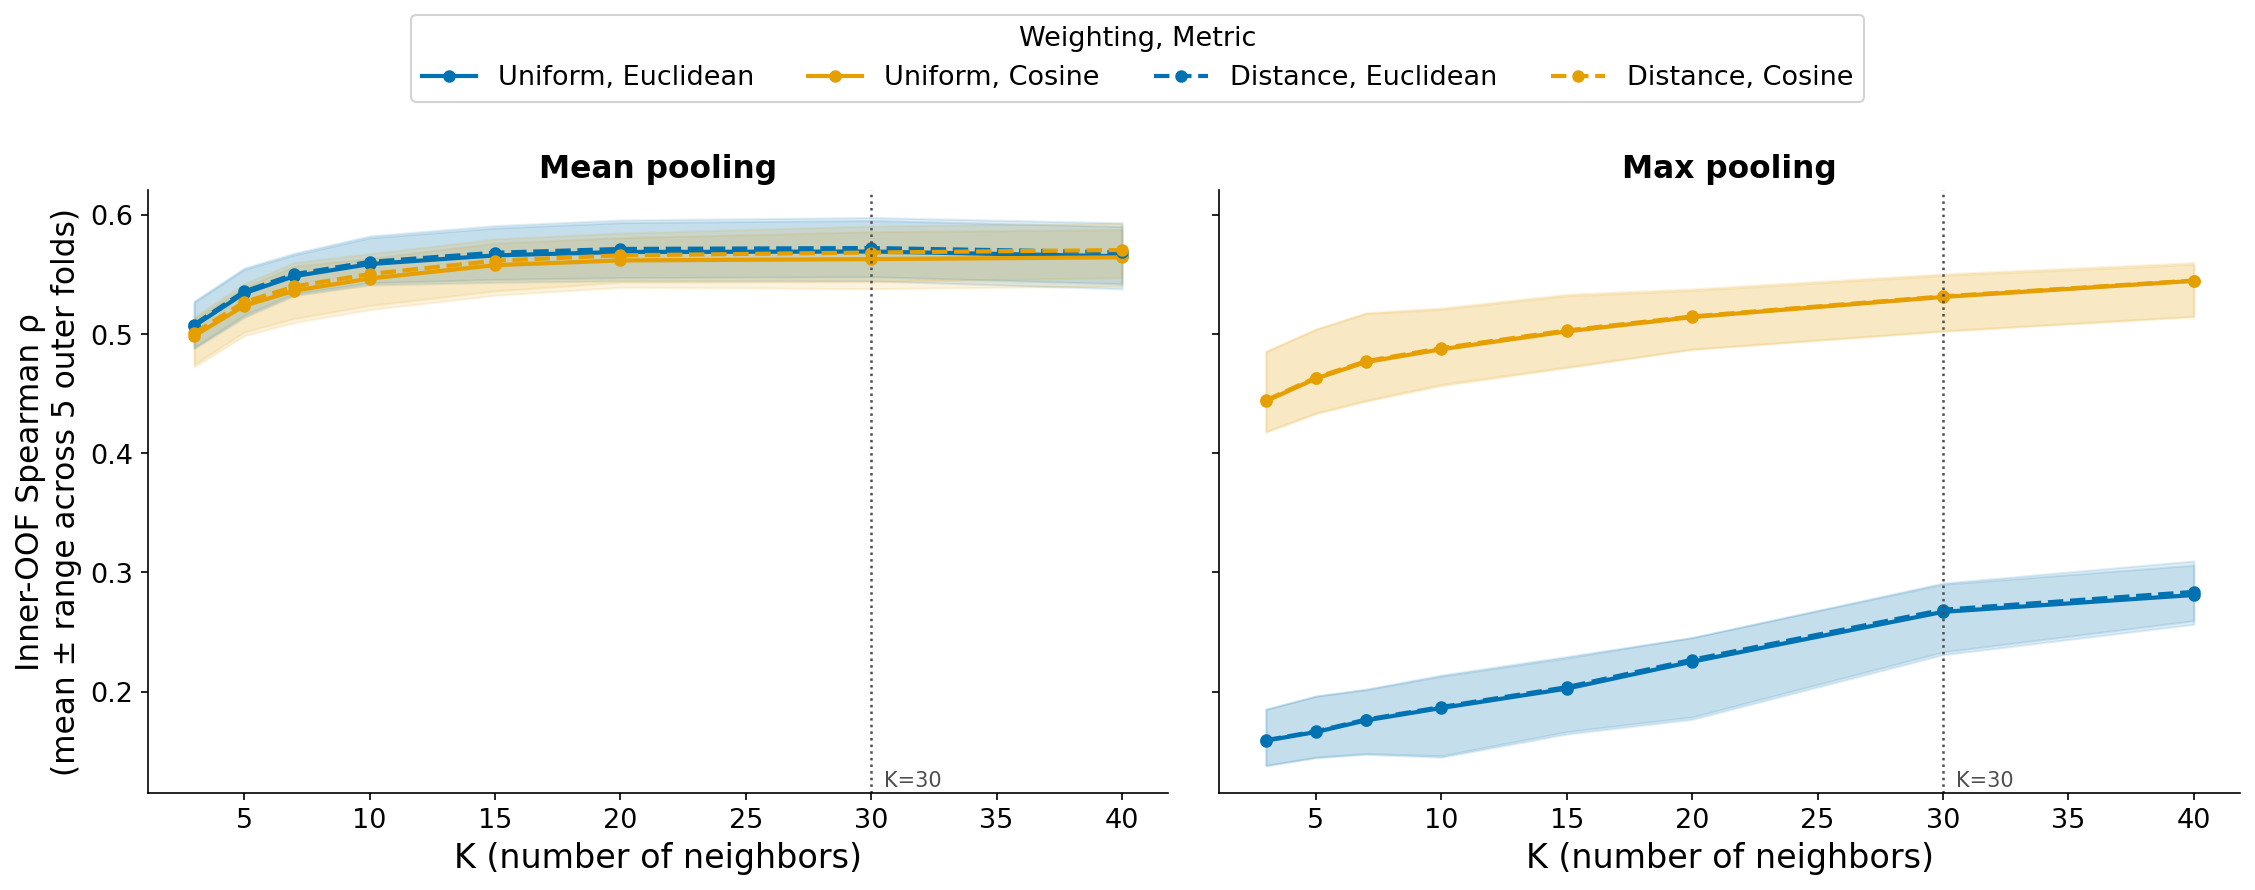

Mean pooling's worst (weights, metric, K) still beats Max pooling's best in every outer fold --
the panels share a y-axis specifically so that vertical separation is visible at a glance.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, pool in zip(axes, POOL_GRID):
    grid = full_grid_df[full_grid_df['pool'] == pool]
    agg = (grid.groupby(['weights', 'metric', 'k'])['inner_rho']
           .agg(['mean', 'min', 'max']).reset_index())
    for weights in WEIGHTS_GRID:
        for metric in METRICS_GRID:
            sub = agg[(agg['weights'] == weights) & (agg['metric'] == metric)].sort_values('k')
            ax.plot(sub['k'], sub['mean'], color=METRIC_COLORS[metric], linestyle=WEIGHT_STYLES[weights],
                    marker='o', markersize=5, linewidth=2, label=f'{weights.capitalize()}, {metric.capitalize()}')
            ax.fill_between(sub['k'], sub['min'], sub['max'], color=METRIC_COLORS[metric], alpha=0.12)
    ax.axvline(30, color='0.3', linestyle=':', linewidth=1.2)
    ax.set_xlabel('K (number of neighbors)', fontsize=16)
    ax.set_title(f'{pool} pooling', fontsize=15, fontweight='bold')
    ax.tick_params(labelsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Inner-OOF Spearman ρ\n(mean ± range across 5 outer folds)', fontsize=15)
axes[0].text(30.5, axes[0].get_ylim()[0] + 0.002, 'K=30', fontsize=10, va='bottom', ha='left', color='0.3')
axes[1].text(30.5, axes[1].get_ylim()[0] + 0.002, 'K=30', fontsize=10, va='bottom', ha='left', color='0.3')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), bbox_transform=fig.transFigure,
           ncol=4, fontsize=13, frameon=True, title='Weighting, Metric', title_fontsize=13)
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.11, top=0.78, wspace=0.05)
plt.show()

print(f"Mean pooling's worst (weights, metric, K) still beats Max pooling's best in every outer fold --")
print(f'the panels share a y-axis specifically so that vertical separation is visible at a glance.')

## Figure: cross-validated performance at the selected optimal hyperparameters

Out-of-fold predictions from a single KNN model at the hyperparameters selected by the search --
Mean pooling, distance-weighted averaging, Euclidean metric, K=30 -- scored with the same 5-fold,
position-grouped cross-validation (`GroupKFold(n_splits=5, shuffle=True, random_state=42)`) used
throughout this notebook, plotted against measured CLICK-seq activity. This is the headline KNN
number reported elsewhere in the paper (Spearman ρ=0.597); the fully nested estimate above
(ρ=0.593) quantifies the small (+0.004) optimism from selecting and reporting the winning 
hyperparameters on the same split.

Optimal-hyperparameter OOF Spearman rho = 0.597  p=0.000e+00  n=6,141


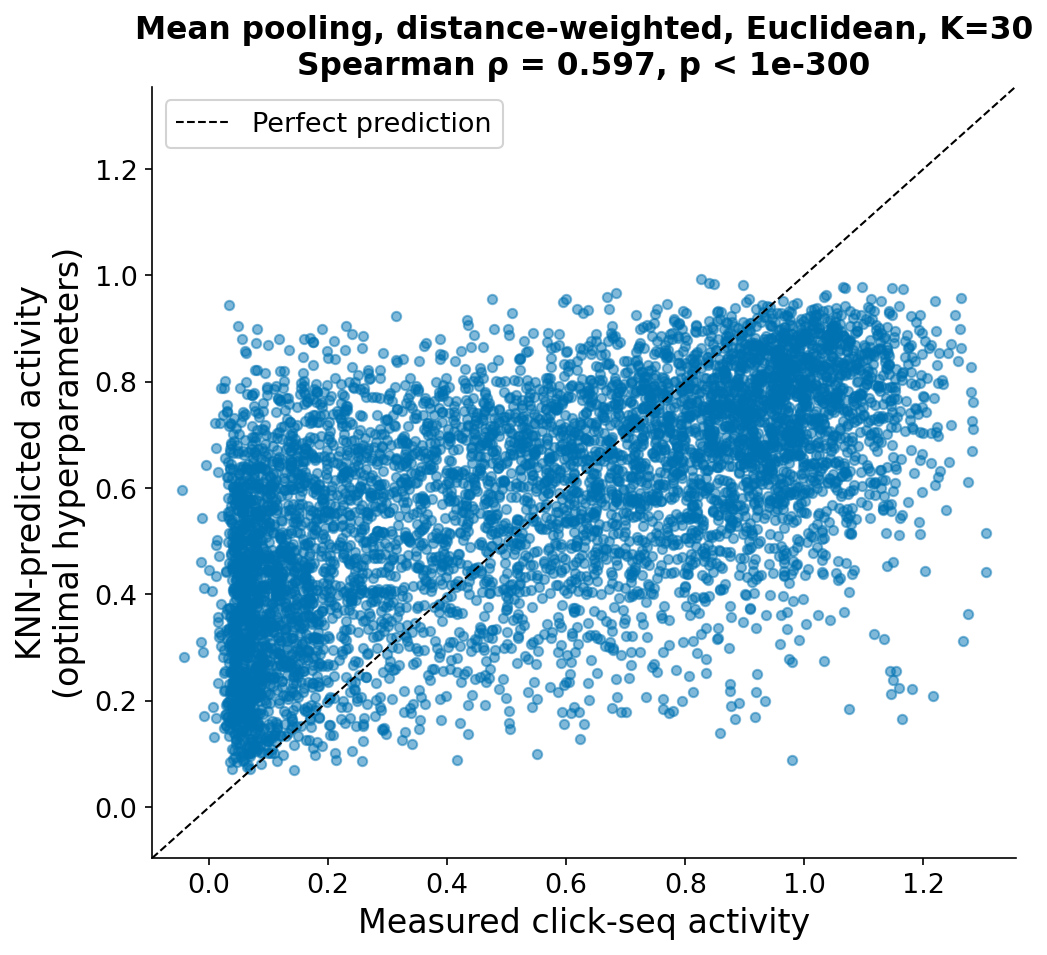

In [7]:
optimal_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=30, weights='distance', metric='euclidean')),
])
optimal_oof = cross_val_predict(optimal_pipe, X_mean, activity, cv=outer_cv, groups=groups)
optimal_rho, optimal_p = spearmanr(optimal_oof, activity)
print(f'Optimal-hyperparameter OOF Spearman rho = {optimal_rho:.3f}  p={optimal_p:.3e}  n={len(activity):,}')

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(activity, optimal_oof, alpha=0.5, s=20, color='#0072B2', rasterized=True)
lims = [activity.min() - 0.05, activity.max() + 0.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Measured click-seq activity', fontsize=16)
ax.set_ylabel('KNN-predicted activity\n(optimal hyperparameters)', fontsize=16)
p_str = f'p = {optimal_p:.3e}' if optimal_p > 0 else 'p < 1e-300'
ax.set_title(f'Mean pooling, distance-weighted, Euclidean, K=30\nSpearman ρ = {optimal_rho:.3f}, {p_str}',
             fontsize=15, fontweight='bold')
ax.tick_params(labelsize=13)
ax.legend(loc='upper left', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()